# 03 · Exploratory data analysis

Goal of the project: day-ahead forecast of daily grid consumption (`gross_load`)
per heat-pump household, with one pooled model across all households. This
notebook is the consolidated EDA: aggregate patterns across households,
household-level dynamics, and what PV does to the target.

**Data:** `data/processed/model_table.parquet` (leakage-safe panel, modelable
rows only), `data/interim/02_clean/weather_daily.parquet` (same-day weather),
`data/interim/02_clean/households.parquet` (master data). The EDA runs on the
cleaned panel, not on `data/raw/` — `gross_load` and `is_modelable` only exist
there, and the delivery itself with its quality issues is covered in notebooks
01/02 (`docs/decisions.md`, D-23).

**Approach:** derive the questions from the project goal first, then decide
plot vs. number. A question answered by a single number gets no plot.

| # | Question | Answered in |
|---|---|---|
| Q1 | What dynamics must the forecast track over time (seasonality, winter peaks)? | §1 (plot) |
| Q2 | How heterogeneous are household levels — does a pooled model carry all households? | §2 (plots) |
| Q3 | How strong and how nonlinear is the temperature dependence? | §3.1–3.2 (plots) |
| Q4 | Does every single household follow the temperature curve? | §3.3 (plot) |
| Q5 | Does PV self-generation distort the target — and how, day by day? | §4.1–4.2 (plots) |
| Q6 | Does PV change day-to-day volatility? | §4.3 (plot) |
| Q7 | Weekday/holiday effects, autocorrelation, weather persistence and redundancy, installation-visit effect | §5 (numbers) |

In [1]:
import calendar
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Repo root relative to the notebook (notebooks/data_understanding/ -> root)
ROOT = Path("..") / ".."
IMAGES = ROOT / "images" / "data_understanding"
IMAGES.mkdir(parents=True, exist_ok=True)

# Color and text roles (validated reference palette, light mode)
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASE, SURFACE = "#e1e0d9", "#c3c2b7", "#ffffff"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "Arial", "DejaVu Sans"],
    "text.color": INK, "axes.labelcolor": INK2, "axes.edgecolor": BASE,
    "xtick.color": BASE, "ytick.color": BASE,
    "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "axes.linewidth": 0.8,
    "axes.labelsize": 10.5, "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "legend.frameon": False, "legend.fontsize": 9.5,
    "figure.dpi": 110,
})


def export(fig, name):
    """Save each figure as vector PDF (report) and PNG (preview)."""
    fig.savefig(IMAGES / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(IMAGES / f"{name}.png", bbox_inches="tight", dpi=200)
    print(f"exported: images/data_understanding/{name}.(pdf|png)")

In [2]:
# Panel and helper tables; the EDA uses modelable rows only
panel = pd.read_parquet(ROOT / "data" / "processed" / "model_table.parquet")
m = panel[panel["is_modelable"]].copy()

wd = pd.read_parquet(ROOT / "data" / "interim" / "02_clean" / "weather_daily.parquet")
hh = pd.read_parquet(ROOT / "data" / "interim" / "02_clean" / "households.parquet")

# PV feed-in is deliberately not in the panel (never a predictor, D-20/D-05);
# loaded from the clean zone for the descriptive PV views in §4
sm_ret = pd.read_parquet(
    ROOT / "data" / "interim" / "02_clean" / "smart_meter_daily.parquet",
    columns=["Household_ID", "date", "kWh_returned_Total"],
)

# Join same-day weather per (station, day). The panel's weather columns carry
# the previous day for leakage reasons; for the physical questions asked here
# the target day is the honest reference (difference is small for daily means).
w = wd.rename(columns={"Weather_ID": "weather_id",
                       "Temperature_avg_hourly_mean": "t_day",
                       "Sunshine_duration_hourly_sum": "sun_day"})[
    ["weather_id", "date", "t_day", "sun_day"]]
w["weather_id"] = w["weather_id"].astype(str)
d = m.assign(weather_id=m["weather_id"].astype(str)).merge(
    w, on=["weather_id", "date"], how="left", validate="m:1")

print(f"panel: {len(panel):,} rows | modelable: {len(m):,} | "
      f"{m['Household_ID'].nunique()} households | "
      f"{m['date'].min().date()} to {m['date'].max().date()}")
print(f"same-day temperature missing: {d['t_day'].isna().mean():.2%} | sunshine "
      f"missing: {d['sun_day'].isna().mean():.2%} (3 of 8 stations without sensor, notebook 02)")

panel: 82,051 rows | modelable: 81,085 | 153 households | 2019-01-02 to 2024-03-01
same-day temperature missing: 0.21% | sunshine missing: 10.08% (3 of 8 stations without sensor, notebook 02)


## 1 — Consumption across all households over calendar time

What dynamics must day-ahead procurement track — how large is the seasonal
swing, how repeatable are the winter peaks?

Caveat: the daily mean across households mixes changing subsets (25–67 active
households per day, notebook 01), so level shifts can be composition effects.
For the seasonal shape the mean is still the right view — procurement buys
exactly this changing portfolio.

exported: images/data_understanding/03_eda_load_seasonality.(pdf|png)


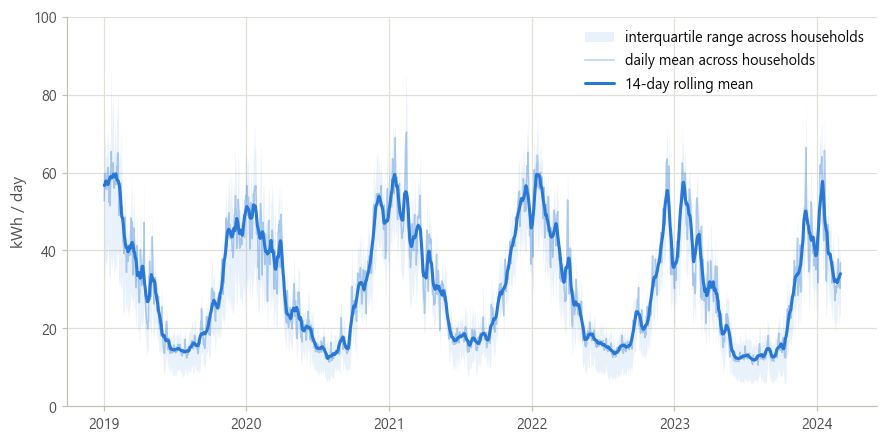

daily mean across households — winter (DJF): 48.4 kWh/day | summer (JJA): 15.3 kWh/day | factor 3.2
peak daily mean: 70.4 kWh/day on 2021-02-14


In [3]:
q = m.groupby("date")["gross_load"].agg(
    mean="mean", q25=lambda s: s.quantile(0.25), q75=lambda s: s.quantile(0.75)
)
roll = q["mean"].rolling(14, center=True, min_periods=7).mean()

fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.fill_between(q.index, q["q25"], q["q75"], color=BLUE, alpha=0.10,
                linewidth=0, label="interquartile range across households")
ax.plot(q.index, q["mean"], color=BLUE, lw=1, alpha=0.35,
        label="daily mean across households")
ax.plot(roll.index, roll.values, color=BLUE, lw=2, solid_capstyle="round",
        label="14-day rolling mean")
ax.set_ylabel("kWh / day")
ax.set_ylim(0, 100)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="upper right", ncol=1)
export(fig, "03_eda_load_seasonality")
plt.show()

winter = q.loc[q.index.month.isin([12, 1, 2]), "mean"]
summer = q.loc[q.index.month.isin([6, 7, 8]), "mean"]
print(f"daily mean across households — winter (DJF): {winter.mean():.1f} kWh/day | "
      f"summer (JJA): {summer.mean():.1f} kWh/day | factor {winter.mean() / summer.mean():.1f}")
print(f"peak daily mean: {q['mean'].max():.1f} kWh/day on {q['mean'].idxmax().date()}")

**Takeaway:** The annual cycle dominates everything: the daily mean across
households swings between ~11 kWh/day in summer and cold-spell peaks around
70 kWh/day — roughly factor 3 between winter and summer means, with short cold
snaps well above. These peaks are the expensive procurement risk; a model that
gets the level right but sleeps through cold spells is useless. The wide
interquartile band already points at the household heterogeneity examined
next (§2).

## 2 — Heterogeneity across households

### 2.1 Distribution of household levels

How different are the consumption levels — can one pooled model carry all
households, and why do the autoregressive features (`recv_lag1`,
`recv_roll7_mean`) matter so much?

exported: images/data_understanding/03_eda_household_heterogeneity.(pdf|png)


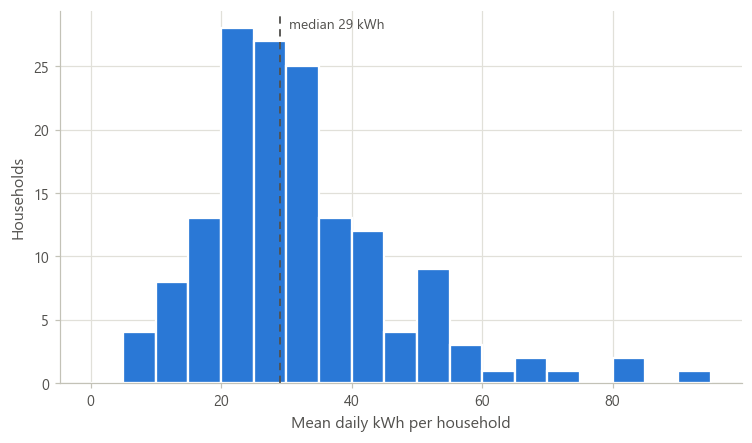

n = 153 households | p5 = 12.2 | median = 29.0 | p95 = 56.9 | max = 93.7 kWh/day
spread p5–p95: factor 4.6


In [4]:
hh_mean = m.groupby("Household_ID", observed=True)["gross_load"].mean()
p5, med, p95 = hh_mean.quantile([0.05, 0.5, 0.95])

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.hist(hh_mean, bins=np.arange(0, 100, 5), color=BLUE,
        edgecolor=SURFACE, linewidth=1.5)
ax.axvline(med, color=INK2, lw=1.2, ls=(0, (4, 3)))
ax.annotate(f"median {med:.0f} kWh", xy=(med, ax.get_ylim()[1]), xytext=(6, -12),
            textcoords="offset points", fontsize=9, color=INK2)
ax.set_xlabel("Mean daily kWh per household")
ax.set_ylabel("Households")
export(fig, "03_eda_household_heterogeneity")
plt.show()

print(f"n = {hh_mean.size} households | p5 = {p5:.1f} | median = {med:.1f} | "
      f"p95 = {p95:.1f} | max = {hh_mean.max():.1f} kWh/day")
print(f"spread p5–p95: factor {p95 / p5:.1f}")

**Takeaway:** Household mean consumption spans ~12 (p5) to ~57 kWh/day (p95),
median 29, maximum 94 — almost factor 5 between p5 and p95. A pooled model
without household information would have to guess these levels; in practice
the autoregressive features carry the level per household (r(y, lag1) = 0.94,
§5), so pooling holds despite the spread. The right skew (a few very large
consumers) also explains why error metrics will vary strongly per household.

### 2.2 Household levels resolved by PV status

Same distribution, resolved to individual households and colored by PV
ownership: does PV split the households into two level groups, or do the
groups interleave?

exported: images/data_understanding/03_eda_household_levels_sorted_pv.(pdf|png)


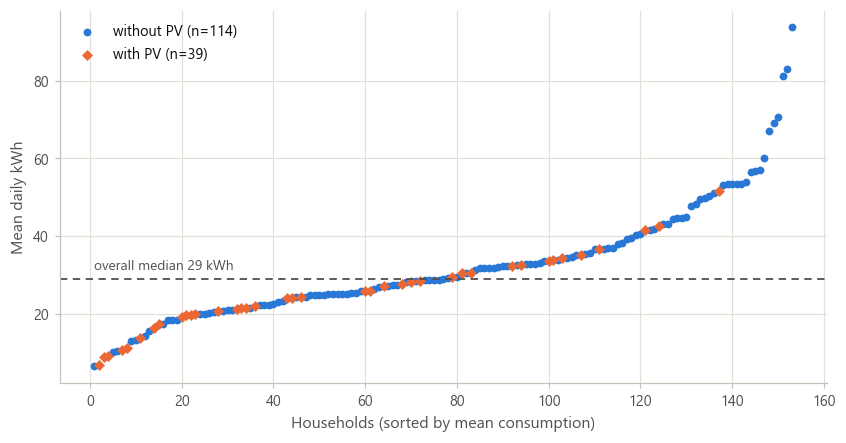

range: 6.5 to 93.7 kWh/day (factor 14)
mean level: PV 25.1 vs. non-PV 34.5 kWh/day | PV households below the overall median: 67%


In [5]:
pv_flag_hh = (m.drop_duplicates("Household_ID").set_index("Household_ID")
                ["Installation_HasPVSystem"].astype(bool))
lv = hh_mean.sort_values().rename("mean_load").reset_index()
lv["rank"] = lv.index + 1
lv["has_pv"] = lv["Household_ID"].map(pv_flag_hh)

fig, ax = plt.subplots(figsize=(9, 4.4))
for flag, color, marker, label in [
    (False, BLUE, "o", f"without PV (n={int((~lv['has_pv']).sum())})"),
    (True, ORANGE, "D", f"with PV (n={int(lv['has_pv'].sum())})"),
]:
    sub = lv[lv["has_pv"] == flag]
    ax.scatter(sub["rank"], sub["mean_load"], s=26, color=color, marker=marker,
               linewidths=0, label=label)
overall_med = lv["mean_load"].median()
ax.axhline(overall_med, color=INK2, lw=1.2, ls=(0, (4, 3)))
ax.annotate(f"overall median {overall_med:.0f} kWh", xy=(1, overall_med), xytext=(0, 6),
            textcoords="offset points", fontsize=9, color=INK2)
ax.set_xlabel("Households (sorted by mean consumption)")
ax.set_ylabel("Mean daily kWh")
ax.legend(loc="upper left")
export(fig, "03_eda_household_levels_sorted_pv")
plt.show()

print(f"range: {lv['mean_load'].min():.1f} to {lv['mean_load'].max():.1f} kWh/day "
      f"(factor {lv['mean_load'].max() / lv['mean_load'].min():.0f})")
print(f"mean level: PV {hh_mean[pv_flag_hh].mean():.1f} vs. non-PV "
      f"{hh_mean[~pv_flag_hh].mean():.1f} kWh/day | PV households below the overall "
      f"median: {(hh_mean[pv_flag_hh] < overall_med).mean():.0%}")

**Takeaway:** PV and non-PV households interleave across the entire range
(6.5–94 kWh/day). PV households sit somewhat lower on average (25 vs.
35 kWh/day, two thirds below the overall median), but PV is far from a level
separator — building and behavior dominate. The per-household level therefore
has to come from autoregression, not from the PV flag (its real role: §4).

## 3 — Temperature as the dominant driver

### 3.1 Temperature–load curve

How strong and in what shape does daily consumption depend on outdoor
temperature — and is the heating threshold at 15 °C (base of `hdd_15`)
plausible? Shown is the physical relationship: consumption on day *d* against
the station temperature of the *same* day (the model itself only sees day d−1,
see setup).

80,912 household-days | r(gross_load, same-day T) = -0.63
y-axis clipped at 130 kWh: affects 0.42% of household-days (max 250 kWh)


exported: images/data_understanding/03_eda_temperature_load_curve.(pdf|png)


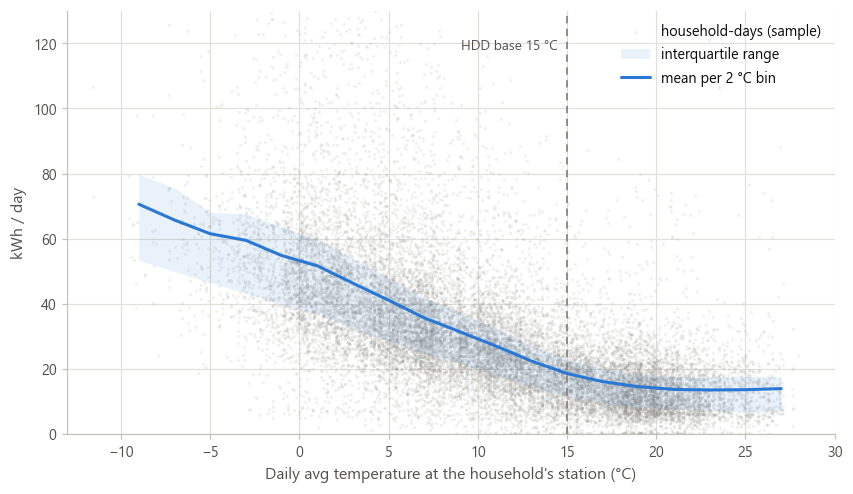

In [6]:
dt = d.dropna(subset=["t_day"])
bins = np.arange(-16, 34, 2.0)
mid = pd.cut(dt["t_day"], bins=bins)
binned = dt.groupby(mid, observed=True)["gross_load"].agg(
    mean="mean", q25=lambda s: s.quantile(0.25), q75=lambda s: s.quantile(0.75), n="size"
)
binned = binned[binned["n"] >= 30]
x = np.array([iv.mid for iv in binned.index])

r = dt["gross_load"].corr(dt["t_day"])
print(f"{len(dt):,} household-days | r(gross_load, same-day T) = {r:.2f}")

fig, ax = plt.subplots(figsize=(9, 5))
smp = dt.sample(20000, random_state=7)
ax.scatter(smp["t_day"], smp["gross_load"], s=4, color=MUTED, alpha=0.12,
           linewidths=0, rasterized=True, label="household-days (sample)")
ax.fill_between(x, binned["q25"], binned["q75"], color=BLUE, alpha=0.10,
                linewidth=0, label="interquartile range")
ax.plot(x, binned["mean"], color=BLUE, lw=2, solid_capstyle="round",
        label="mean per 2 °C bin")
ax.axvline(15, color=MUTED, lw=1.2, ls=(0, (4, 3)))
ax.annotate("HDD base 15 °C", xy=(15, 118), xytext=(-6, 0),
            textcoords="offset points", ha="right", fontsize=9, color=INK2)
ax.set_xlabel("Daily avg temperature at the household's station (°C)")
ax.set_ylabel("kWh / day")
ax.set_xlim(np.floor(dt["t_day"].min()) - 1, np.ceil(dt["t_day"].max()) + 1)
ax.set_ylim(0, 130)
clipped = (dt["gross_load"] > 130).mean()
print(f"y-axis clipped at 130 kWh: affects {clipped:.2%} of household-days "
      f"(max {dt['gross_load'].max():.0f} kWh)")
ax.legend(loc="upper right")
export(fig, "03_eda_temperature_load_curve")
plt.show()

**Takeaway:** The classic heat-pump signature — below ~15 °C the mean rises
roughly linearly from ~16 to ~68 kWh/day (at −15 °C); above it sits a flat
summer plateau around 14–16 kWh (hot water + household electricity). The kink
supports the HDD base of 15 °C used in the pipeline (D-10). The large vertical
spread at equal temperature is the household effect from §2. (Display: y-axis
clipped at 130 kWh — 0.4 % of household-days, maximum 250 kWh; the share is
computed in the cell output.)

### 3.2 Daily view across households: one point per calendar day

Averaging across households cancels out the household spread — how much of
the day-to-day demand of all households together does temperature alone
explain? Mean daily consumption across households vs. mean same-day
temperature across households, colored by meteorological season, with a
simple OLS fit as reference.

exported: images/data_understanding/03_eda_temperature_scatter_daily.(pdf|png)


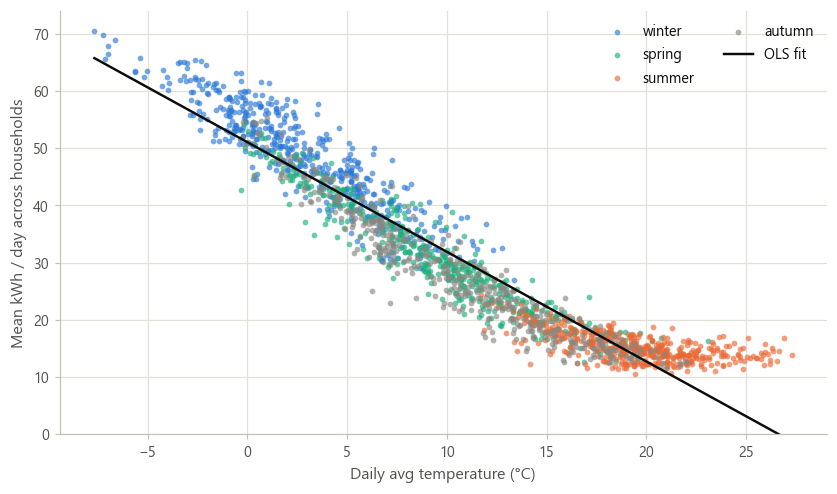

1,885 days | r = -0.95, R² = 0.91 | slope -1.9 kWh per +1 °C


In [7]:
daily = (d.dropna(subset=["t_day"]).groupby("date")
           .agg(load=("gross_load", "mean"), temp=("t_day", "mean")))
season_map = {12: "winter", 1: "winter", 2: "winter", 3: "spring", 4: "spring",
              5: "spring", 6: "summer", 7: "summer", 8: "summer",
              9: "autumn", 10: "autumn", 11: "autumn"}
daily["season"] = daily.index.month.map(season_map)
season_colors = {"winter": BLUE, "spring": AQUA, "summer": ORANGE, "autumn": MUTED}

r_daily = daily["load"].corr(daily["temp"])
slope, intercept = np.polyfit(daily["temp"], daily["load"], 1)

fig, ax = plt.subplots(figsize=(9, 5))
for season, color in season_colors.items():
    sub = daily[daily["season"] == season]
    ax.scatter(sub["temp"], sub["load"], s=14, color=color, alpha=0.65,
               linewidths=0, label=season)
xl = np.array([daily["temp"].min(), daily["temp"].max()])
ax.plot(xl, slope * xl + intercept, color=INK, lw=1.6, label="OLS fit")
ax.set_xlabel("Daily avg temperature (°C)")
ax.set_ylabel("Mean kWh / day across households")
ax.set_ylim(0, 74)
ax.legend(loc="upper right", ncol=2)
export(fig, "03_eda_temperature_scatter_daily")
plt.show()

print(f"{len(daily):,} days | r = {r_daily:.2f}, R² = {r_daily ** 2:.2f} | "
      f"slope {slope:.1f} kWh per +1 °C")

**Takeaway:** Averaged per day across households, temperature alone explains
~91 % of the day-to-day variance (r = −0.95, ≈ −1.9 kWh per +1 °C): the level
noise that dilutes the pooled household-day correlation (−0.63, §3.1)
averages out. The seasons line up along one line rather than forming separate
regimes; only the warmest days flatten off toward the summer plateau,
consistent with the kink in §3.1.

### 3.3 Does every household carry the curve?

The pooled picture could be carried by a few large consumers while others do
not react to temperature at all. Pearson correlation between daily consumption
and same-day temperature, per household, for all households (a `min_days`
guard is kept in the code, currently 0 — short histories make the estimate
noisy, see the diagnostics below). Reference lines: pooled correlation and
household median.

153 of 153 households with a computable correlation (min_days = 0, 0 excluded)
pooled r = -0.63 | per household: median -0.84, IQR -0.91 to -0.72, range -0.97 to +1.00
share r < -0.7: 78% | share r > -0.3: 4.6% (7 households)


exported: images/data_understanding/03b_eda_household_temperature_response.(pdf|png)


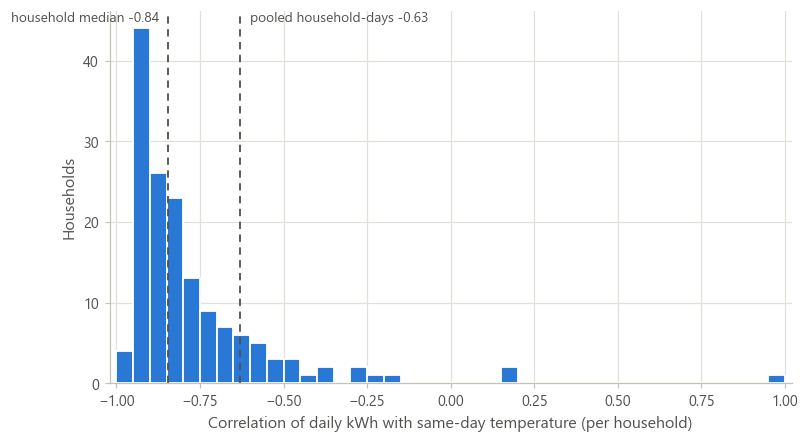


weak responders (r > -0.3):
              days  cold_days  t_min    r
Household_ID                             
1037311        686        147   -3.1 -0.3
105900          74         53   -6.3  0.2
109104           2          0    6.8  1.0
1111201         39          0    6.3 -0.2
122850         209         49   -1.7 -0.2
512280           5          5   -2.6  0.2
876790         143          0    8.3 -0.3


In [8]:
# Within-household correlation r(gross_load, same-day T), vectorized
g = d.dropna(subset=["t_day"])[["Household_ID", "gross_load", "t_day"]]
mu = g.groupby("Household_ID", observed=True)[["gross_load", "t_day"]].transform("mean")
dev = g[["gross_load", "t_day"]] - mu
key = g["Household_ID"]
num = (dev["gross_load"] * dev["t_day"]).groupby(key, observed=True).sum()
den = np.sqrt((dev["gross_load"] ** 2).groupby(key, observed=True).sum()
              * (dev["t_day"] ** 2).groupby(key, observed=True).sum())
n_days = g.groupby("Household_ID", observed=True).size()
min_days = 0  # structural guard against too-short histories; 0 keeps all
r_hh = (num / den.replace(0, np.nan))[n_days >= min_days].dropna()

r_pooled = g["gross_load"].corr(g["t_day"])
r_med = r_hh.median()
print(f"{len(r_hh)} of {n_days.size} households with a computable correlation "
      f"(min_days = {min_days}, {n_days.size - len(r_hh)} excluded)")
print(f"pooled r = {r_pooled:+.2f} | per household: median {r_med:+.2f}, "
      f"IQR {r_hh.quantile(0.25):+.2f} to {r_hh.quantile(0.75):+.2f}, "
      f"range {r_hh.min():+.2f} to {r_hh.max():+.2f}")
print(f"share r < -0.7: {(r_hh < -0.7).mean():.0%} | share r > -0.3: "
      f"{(r_hh > -0.3).mean():.1%} ({int((r_hh > -0.3).sum())} households)")

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.hist(r_hh, bins=np.arange(-1.0, 1.01, 0.05), color=BLUE,
        edgecolor=SURFACE, linewidth=1.2)
ymax = ax.get_ylim()[1]
ax.axvline(r_med, color=INK2, lw=1.2, ls=(0, (4, 3)))
ax.annotate(f"household median {r_med:+.2f}", xy=(r_med, ymax * 0.97),
            xytext=(-6, 0), textcoords="offset points", ha="right",
            fontsize=9, color=INK2)
ax.axvline(r_pooled, color=INK2, lw=1.2, ls=(0, (4, 3)))
ax.annotate(f"pooled household-days {r_pooled:+.2f}", xy=(r_pooled, ymax * 0.97),
            xytext=(6, 0), textcoords="offset points", ha="left",
            fontsize=9, color=INK2)
ax.set_xlabel("Correlation of daily kWh with same-day temperature (per household)")
ax.set_ylabel("Households")
ax.set_xlim(-1.02, 1.02)
export(fig, "03b_eda_household_temperature_response")
plt.show()

# Diagnose the few weak responders instead of ignoring them
weak = r_hh[r_hh > -0.3]
info = d.dropna(subset=["t_day"]).groupby("Household_ID", observed=True).agg(
    days=("gross_load", "size"),
    cold_days=("t_day", lambda s: int((s < 5).sum())),
    t_min=("t_day", "min"))
print("\nweak responders (r > -0.3):")
print(info.loc[weak.index].assign(r=weak.round(2)).round(1).to_string())

**Takeaway:** The temperature dependence is no aggregation artifact: 78 % of
households correlate stronger than r = −0.7 with same-day temperature, median
−0.84 — notably *stronger* than the pooled −0.63, because pooling lets the
level spread (§2) act as noise. Only 7 of 153 households respond weakly
(r > −0.3), and five of them lack usable contrast: three never saw a cold day
(summer-only delivery; the r = +1.00 outlier has just 2 days), two more have
short histories (5 and 74 days) — leaving at most two real exceptions (686
and 209 delivery days). The households heat electrically almost without
exception, while the *strength* of the response varies (IQR −0.91 to −0.72).

## 4 — PV and what the target measures

`gross_load` is gross *grid draw*, not consumption. 39 of the 153 households
have PV: self-consumption bypasses the meter, feed-in is measured separately
(`kWh_returned_Total`, bidirectional meter at the grid connection point —
deliberately not in the panel, never a predictor, D-20/D-05).

### 4.1 Monthly profile of grid draw — with and without feed-in

Do PV households draw systematically less, and when — and is their summer dip
really PV-driven? Monthly **median** per group, robust against the right-skewed
levels (§2); the mean-based view across all households is §1. Two variants of
the same chart, exported separately so the report can use either: the pure
target view, and the same chart with the measured feed-in overlaid. Energy
balance for reading the second one: generation = self-consumption + feed-in;
only self-consumption is invisible to the meter and can only be approximated
via the draw gap to non-PV households.

exported: images/data_understanding/03_eda_pv_monthly_profile_median.(pdf|png)


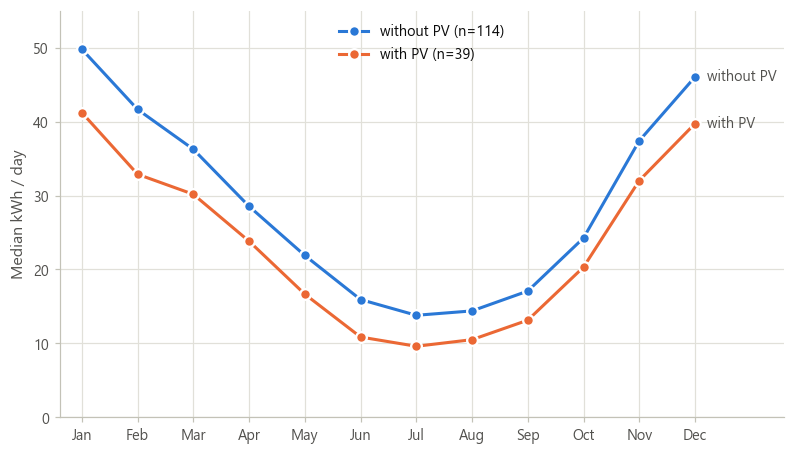

PV households draw less than non-PV (median): summer (Jun–Aug) 30 % | winter (Dec–Feb) 17 %


In [9]:
# Monthly medians per group; feed-in joined from the clean zone (see setup)
prof = (m.assign(month=m["date"].dt.month)
          .groupby(["Installation_HasPVSystem", "month"], observed=True)["gross_load"]
          .median().unstack(0))
n_pv = int(m.drop_duplicates("Household_ID")["Installation_HasPVSystem"].sum())
n_all = m["Household_ID"].nunique()

mr = m.merge(sm_ret, on=["Household_ID", "date"], how="left", validate="1:1")
ret = (mr[mr["Installation_HasPVSystem"]]
       .assign(month=lambda t: t["date"].dt.month)
       .groupby("month", observed=True)["kWh_returned_Total"].median())

# Variant 1 — the pure target view, no feed-in
fig, ax = plt.subplots(figsize=(8.5, 4.8))
months = prof.index.to_numpy()
for flag, color, label in [
    (False, BLUE, f"without PV (n={n_all - n_pv})"),
    (True, ORANGE, f"with PV (n={n_pv})"),
]:
    y = prof[flag].to_numpy()
    ax.plot(months, y, color=color, lw=2, marker="o", markersize=7,
            markeredgecolor=SURFACE, markeredgewidth=1.5, label=label)
    ax.annotate(label.split(" (")[0], xy=(months[-1], y[-1]), xytext=(8, 0),
                textcoords="offset points", va="center", fontsize=9.5, color=INK2)

ax.set_xticks(months, [calendar.month_abbr[int(v)] for v in months])
ax.set_ylabel("Median kWh / day")
ax.set_ylim(0, 55)
ax.set_xlim(0.6, 13.6)
ax.legend(loc="upper center")
export(fig, "03_eda_pv_monthly_profile_median")
plt.show()

rel = (1 - prof[True] / prof[False]) * 100
print(f"PV households draw less than non-PV (median): summer (Jun–Aug) "
      f"{rel[[6, 7, 8]].mean():.0f} % | winter (Dec–Feb) {rel[[12, 1, 2]].mean():.0f} %")

exported: images/data_understanding/03_eda_pv_monthly_profile_median_feedin.(pdf|png)


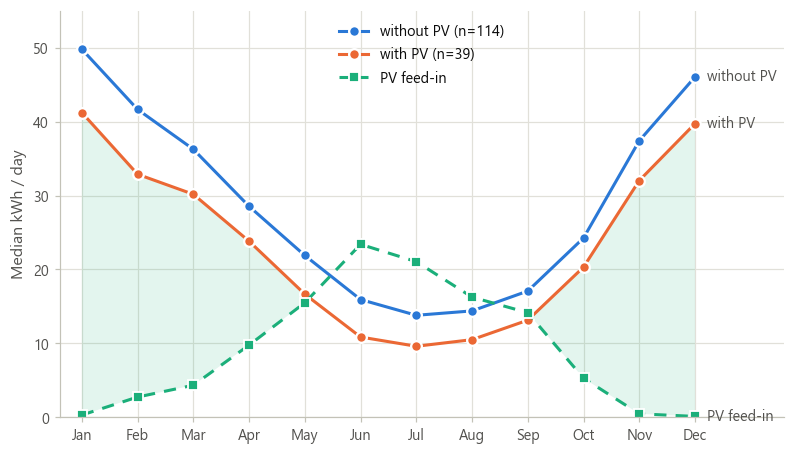

PV feed-in (median): summer 20.2 | winter 1.1 kWh/day | peak 23.4 in Jun
months with feed-in above PV draw (net export in the median): ['Jun', 'Jul', 'Aug', 'Sep']
draw gap non-PV − PV (median): summer 4.4 | winter 7.9 kWh/day
naive generation estimate, summer (gap + feed-in): 24.6 kWh/day — upper bound, see takeaway
measurement gaps: 47% of PV household-days lack a feed-in value (median per household 9%, 5/39 households > 90 %)


In [10]:
# Variant 2 — same chart with the measured feed-in overlaid; the shaded band
# between PV draw and feed-in marks the months where the median PV household
# is still a net importer
fig, ax = plt.subplots(figsize=(8.5, 4.8))
for flag, color, label in [
    (False, BLUE, f"without PV (n={n_all - n_pv})"),
    (True, ORANGE, f"with PV (n={n_pv})"),
]:
    y = prof[flag].to_numpy()
    ax.plot(months, y, color=color, lw=2, marker="o", markersize=7,
            markeredgecolor=SURFACE, markeredgewidth=1.5, label=label)
    ax.annotate(label.split(" (")[0], xy=(months[-1], y[-1]), xytext=(8, 0),
                textcoords="offset points", va="center", fontsize=9.5, color=INK2)

y_pv = prof[True].to_numpy()
y_ret = ret.to_numpy()
ax.plot(months, y_ret, color=AQUA, lw=2, ls=(0, (4, 3)), marker="s",
        markersize=6, markeredgecolor=SURFACE, markeredgewidth=1.2,
        label="PV feed-in")
ax.annotate("PV feed-in", xy=(months[-1], y_ret[-1]), xytext=(8, 0),
            textcoords="offset points", va="center", fontsize=9.5, color=INK2)
ax.fill_between(months, y_pv, y_ret, where=y_pv > y_ret, interpolate=True,
                color=AQUA, alpha=0.12, linewidth=0)

ax.set_xticks(months, [calendar.month_abbr[int(v)] for v in months])
ax.set_ylabel("Median kWh / day")
ax.set_ylim(0, 55)
ax.set_xlim(0.6, 13.6)
ax.legend(loc="upper center")
export(fig, "03_eda_pv_monthly_profile_median_feedin")
plt.show()

gap = prof[False] - prof[True]
print(f"PV feed-in (median): summer {ret[[6, 7, 8]].mean():.1f} | winter "
      f"{ret[[12, 1, 2]].mean():.1f} kWh/day | peak {ret.max():.1f} in "
      f"{calendar.month_abbr[int(ret.idxmax())]}")
print(f"months with feed-in above PV draw (net export in the median): "
      f"{[calendar.month_abbr[int(i)] for i in ret[ret > prof[True]].index]}")
print(f"draw gap non-PV − PV (median): summer {gap[[6, 7, 8]].mean():.1f} | winter "
      f"{gap[[12, 1, 2]].mean():.1f} kWh/day")
print(f"naive generation estimate, summer (gap + feed-in): "
      f"{(gap[[6, 7, 8]] + ret[[6, 7, 8]]).mean():.1f} kWh/day — upper bound, see takeaway")

# Measurement-gap caveat (D-12): active feeders keep NaN as true gaps
pv_ret = mr.loc[mr["Installation_HasPVSystem"], ["Household_ID", "kWh_returned_Total"]]
nan_hh = pv_ret.groupby("Household_ID", observed=True)["kWh_returned_Total"].apply(
    lambda s: s.isna().mean())
print(f"measurement gaps: {pv_ret['kWh_returned_Total'].isna().mean():.0%} of PV "
      f"household-days lack a feed-in value (median per household "
      f"{nan_hh.median():.0%}, {(nan_hh > 0.9).sum()}/{len(nan_hh)} households > 90 %)")

**Takeaway:** PV households draw less in the median throughout — ~30 % in
summer, ~17 % in winter — and the feed-in curve mirrors the season (median
~20 kWh/day in summer vs. ~1 in winter, June peak 23), so the summer dip is
clearly PV-driven. From June to September feed-in exceeds draw — the median
PV household is a net *exporter*, and the shaded net-draw band closes. The
winter gap (~8 kWh/day), however, occurs while generation is minimal: a large
part of it is a *structural* effect (PV owners live in different buildings),
not self-consumption — which makes the naive generation estimate (gap +
feed-in, ~25 kWh/day in summer) an upper bound. For a quarter of the
households the target measures residual draw after self-consumption; this
justifies `Installation_HasPVSystem` as a feature and the planned PV
segmentation (D-20), and it is why the handover contract deliberately calls
the quantity `gross_load` (D-21). Caveat: active feeders keep true
measurement gaps (D-12); monthly medians run over the available values.

### 4.2 Sunshine and the zero floor

The monthly mean hides the daily mechanics: self-generation should cut grid
draw exactly on *sunny* days — down to near-zero. May–September only, so the
heat-pump load does not mask the solar effect; x-axis is same-day sunshine
duration at the household's station (5 of 8 stations have the sensor). Sunny
days are also warmer days, so *both* groups fall with sunshine — the
PV-specific effect sits in the lower tail, hence median, IQR band and 10th
percentile per group.

May–Sep at sunshine stations: 29,590 household-days | 32 households with PV, 85 without
mean same-day temperature per sunshine bin: [14.2, 16.1, 16.9, 17.5, 18.7, 19.0, 20.4, 19.8] °C — sunny also means warm


exported: images/data_understanding/03b_eda_sunshine_grid_draw_pv.(pdf|png)


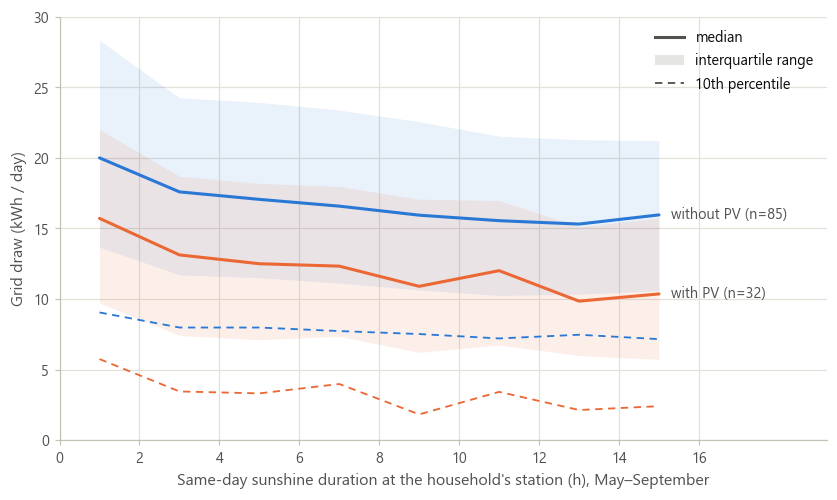


share of days with grid draw < 1 kWh per sunshine bin (%):
               without PV  with PV
sun_bin                           
(-0.001, 2.0]         0.0      3.7
(2.0, 4.0]            0.0      7.2
(4.0, 6.0]            0.0      7.0
(6.0, 8.0]            0.0      5.7
(8.0, 10.0]           0.0      8.5
(10.0, 12.0]          0.0      7.8
(12.0, 14.0]          0.0      8.3
(14.0, 16.0]          0.0      9.0

year-round, all stations: days < 1 kWh — with PV 2.8%, without PV 0.00% (minimum without PV: 1.34 kWh)


In [11]:
s = d[d["date"].dt.month.isin([5, 6, 7, 8, 9])].dropna(subset=["sun_day"]).copy()
s["sun_bin"] = pd.cut(s["sun_day"], bins=np.arange(0, 19, 2), include_lowest=True)
pv_mask = s["Installation_HasPVSystem"].astype(bool)
n_pv_s = s.loc[pv_mask, "Household_ID"].nunique()
n_np_s = s.loc[~pv_mask, "Household_ID"].nunique()
print(f"May–Sep at sunshine stations: {len(s):,} household-days | "
      f"{n_pv_s} households with PV, {n_np_s} without")
print(f"mean same-day temperature per sunshine bin: "
      f"{s.groupby('sun_bin', observed=True)['t_day'].mean().round(1).tolist()} °C "
      f"— sunny also means warm")

qs = (s.groupby([pv_mask, "sun_bin"], observed=True)["gross_load"]
        .quantile([0.10, 0.25, 0.50, 0.75]).unstack())
nz = (s.groupby([pv_mask, "sun_bin"], observed=True)["gross_load"]
        .agg(share_lt1=lambda v: (v < 1.0).mean(), n="size"))

fig, ax = plt.subplots(figsize=(9, 5))
for flag, color, label in [(False, BLUE, f"without PV (n={n_np_s})"),
                           (True, ORANGE, f"with PV (n={n_pv_s})")]:
    qq = qs.loc[flag]
    xq = np.array([iv.mid for iv in qq.index])
    ax.fill_between(xq, qq[0.25], qq[0.75], color=color, alpha=0.10, linewidth=0)
    ax.plot(xq, qq[0.50], color=color, lw=2, solid_capstyle="round")
    ax.plot(xq, qq[0.10], color=color, lw=1.2, ls=(0, (4, 3)))
    ax.annotate(label, xy=(xq[-1], qq[0.50].iloc[-1]), xytext=(8, 0),
                textcoords="offset points", va="center", fontsize=9.5, color=INK2)

handles = [Line2D([], [], color=INK2, lw=2, label="median"),
           Patch(facecolor=INK2, alpha=0.15, label="interquartile range"),
           Line2D([], [], color=INK2, lw=1.2, ls=(0, (4, 3)), label="10th percentile")]
ax.legend(handles=handles, loc="upper right")
ax.set_xlabel("Same-day sunshine duration at the household's station (h), May–September")
ax.set_ylabel("Grid draw (kWh / day)")
ax.set_xticks(np.arange(0, 17, 2))
ax.set_xlim(0, 19.2)
ax.set_ylim(0, 30)
export(fig, "03b_eda_sunshine_grid_draw_pv")
plt.show()

print("\nshare of days with grid draw < 1 kWh per sunshine bin (%):")
tab = (nz["share_lt1"].unstack(0) * 100).round(1)
tab.columns = ["without PV", "with PV"]
print(tab.to_string())
pv_all = m["Installation_HasPVSystem"].astype(bool)
lt1 = m.groupby(pv_all, observed=True)["gross_load"].agg(lambda v: (v < 1.0).mean())
print(f"\nyear-round, all stations: days < 1 kWh — with PV {lt1[True]:.1%}, "
      f"without PV {lt1[False]:.2%} (minimum without PV: "
      f"{m.loc[~pv_all, 'gross_load'].min():.2f} kWh)")

**Takeaway:** Both groups draw less on sunny days — largely the temperature
effect. The difference sits in the lower tail: the 10th percentile without PV
stays at ~7–9 kWh across all sunshine bins (a hot-water/appliance floor that
never disappears), while with PV it falls from ~6 to ~2 kWh and the share of
days below 1 kWh rises from ~4 % to ~9 %; without PV a day below 1 kWh never
occurs (minimum 1.3 kWh). Year-round, 2.8 % of all PV household-days are below
1 kWh. On sunny days PV grid draw is not just lower but *censored* — what the
household actually consumes is no longer readable from the meter.

### 4.3 Day-to-day variability within households

Second dimension of heterogeneity: how much does a household fluctuate around
its own level — and does PV make grid draw systematically noisier (§4.2
suggests so)? Coefficient of variation (std / mean) of daily draw per
household, for all households (a `min_days` guard is kept in the code,
currently 0), as a boxplot per group (median and quartiles) with every
household overlaid as a jittered point — the 39 PV households stay
individually visible.

exported: images/data_understanding/03_eda_daily_volatility_pv_box.(pdf|png)


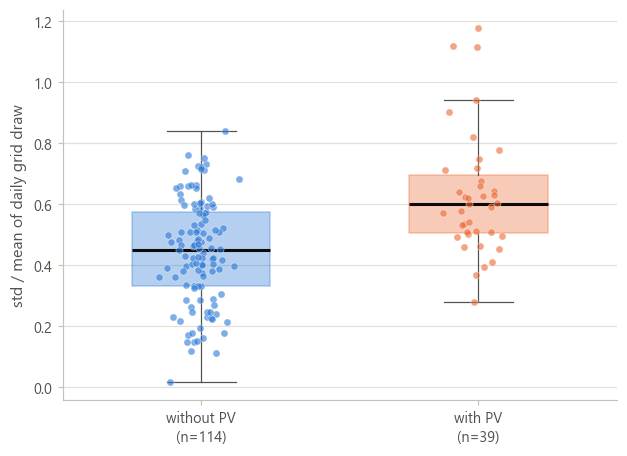

with PV:    n = 39, median 0.60, IQR 0.51–0.69
without PV: n = 114, median 0.45, IQR 0.33–0.57
overlap: 20% of non-PV households vary more than the PV median; 10% of PV households less than the non-PV median


In [12]:
grp = m.groupby("Household_ID", observed=True)["gross_load"]
min_days = 0  # structural guard against too-short histories; 0 keeps all
cv = (grp.std() / grp.mean())[grp.size() >= min_days].dropna().rename("cv")
pv_flag_cv = pv_flag_hh.reindex(cv.index)
groups = [cv[~pv_flag_cv], cv[pv_flag_cv]]
box_colors = [BLUE, ORANGE]

fig, ax = plt.subplots(figsize=(6.5, 4.6))
bp = ax.boxplot(groups, showfliers=False, patch_artist=True, widths=0.5,
                tick_labels=[f"without PV\n(n={len(groups[0])})",
                             f"with PV\n(n={len(groups[1])})"],
                medianprops={"color": INK, "linewidth": 2},
                whiskerprops={"color": INK2, "linewidth": 0.8},
                capprops={"color": INK2, "linewidth": 0.8})
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.35)
    patch.set_edgecolor(color)

rng = np.random.default_rng(7)
for i, (vals, color) in enumerate(zip(groups, box_colors), start=1):
    xj = rng.normal(i, 0.06, len(vals))
    ax.scatter(xj, vals, s=22, color=color, alpha=0.6,
               edgecolor=SURFACE, linewidth=0.4, zorder=3)

ax.set_ylabel("std / mean of daily grid draw")
ax.grid(axis="x", visible=False)
export(fig, "03_eda_daily_volatility_pv_box")
plt.show()

cv_pv, cv_np = cv[pv_flag_cv], cv[~pv_flag_cv]
print(f"with PV:    n = {len(cv_pv)}, median {cv_pv.median():.2f}, "
      f"IQR {cv_pv.quantile(0.25):.2f}–{cv_pv.quantile(0.75):.2f}")
print(f"without PV: n = {len(cv_np)}, median {cv_np.median():.2f}, "
      f"IQR {cv_np.quantile(0.25):.2f}–{cv_np.quantile(0.75):.2f}")
print(f"overlap: {(cv_np > cv_pv.median()).mean():.0%} of non-PV households vary more "
      f"than the PV median; {(cv_pv < cv_np.median()).mean():.0%} of PV households "
      f"less than the non-PV median")

**Takeaway:** PV shifts the distribution visibly upward (median 0.60 vs.
0.45): self-generation couples grid draw to the day's weather and makes it
noisier relative to its own level — consistent with the zero floor in §4.2.
But the distributions do not separate: 20 % of non-PV households vary more
than the PV median, 10 % of PV households less than the non-PV median. The PV
flag marks a tendency, not a class.

## 5 — Secondary effects and persistence (numbers, no plots)

Six questions where a single number answers the question; a plot would only
show that there is little to see.

In [13]:
# Weekday rhythm
dow = m.groupby("dow")["gross_load"].mean()
lift = dow[[5, 6]].mean() / dow[[0, 1, 2, 3, 4]].mean() - 1
print(f"weekday rhythm: Mon–Fri {dow[:5].mean():.1f} kWh, Sat–Sun {dow[5:].mean():.1f} kWh "
      f"→ weekend lift only {lift:+.1%}")

# Holidays, month-matched against normal weekdays
cal_m = m.assign(month=m["date"].dt.month)
wk = cal_m[cal_m["dow"] < 5]
per_hol = (wk.groupby(["month", "is_holiday"], observed=True)["gross_load"]
             .mean().unstack().dropna())
hol_lift = (per_hol[True] / per_hol[False]).mean() - 1
print(f"holidays: {hol_lift:+.1%} vs. normal weekdays of the same month "
      f"({len(per_hol)} months with holidays) — single-digit percent, like the weekend")

# Autocorrelation of the target
r1 = m["gross_load"].corr(m["recv_lag1"])
r7 = m["gross_load"].corr(m["recv_lag7"])
print(f"autocorrelation: r(y, lag1) = {r1:.2f}, r(y, lag7) = {r7:.2f} "
      f"→ strongest single predictors, justifies the active lag features")

# Installation-visit effect — naive vs. month-matched (households with known visit day)
vis = hh.loc[hh["visit_date"].notna(), ["Household_ID", "visit_date"]].copy()
v = m.merge(vis, on="Household_ID", how="inner")
v = v[v["date"] != v["visit_date"]]
v["phase"] = np.where(v["date"] < v["visit_date"], "before", "after")
v["month"] = v["date"].dt.month
per_v = (v.groupby(["Household_ID", "month", "phase"], observed=True)["gross_load"]
           .mean().unstack().dropna())
ratio = (per_v["after"] / per_v["before"]).groupby("Household_ID").mean()
naive = (v.groupby(["Household_ID", "phase"], observed=True)["gross_load"]
           .mean().unstack().dropna())
print(f"visit effect (n={len(ratio)} households with known visit day): "
      f"naive {100 * ((naive['after'] / naive['before']).median() - 1):+.0f} %, "
      f"month-matched {100 * (ratio.median() - 1):+.0f} % (median) — before/after cover "
      f"different seasons; treat is_post_visit as a control variable, not a story")

weekday rhythm: Mon–Fri 29.8 kWh, Sat–Sun 31.4 kWh → weekend lift only +5.3%
holidays: -3.4% vs. normal weekdays of the same month (6 months with holidays) — single-digit percent, like the weekend
autocorrelation: r(y, lag1) = 0.94, r(y, lag7) = 0.87 → strongest single predictors, justifies the active lag features


visit effect (n=54 households with known visit day): naive +28 %, month-matched -8 % (median) — before/after cover different seasons; treat is_post_visit as a control variable, not a story


In [14]:
# Weather persistence — how much does yesterday know about today?
ws = wd.sort_values(["Weather_ID", "date"]).copy()
for col, name in [("Temperature_avg_hourly_mean", "temperature"),
                  ("Sunshine_duration_hourly_sum", "sunshine")]:
    ws["_lag"] = ws.groupby("Weather_ID")[col].shift(1)
    rs = [t[col].corr(t["_lag"])
          for _, t in ws.dropna(subset=[col, "_lag"]).groupby("Weather_ID")]
    rs = [r for r in rs if pd.notna(r)]
    print(f"{name} persistence r(x_d, x_d-1) per station: "
          f"{min(rs):.2f} to {max(rs):.2f} ({len(rs)} stations)")
print("→ temperature is sluggish — the previous day carries almost the full "
      "information; sunshine flips much faster")

# Redundancy within the temperature family
fam = ["Temperature_avg_hourly_mean", "Temperature_avg_hourly_min",
       "Temperature_avg_hourly_max", "DewPoint_hourly_mean"]
off = wd[fam].corr().abs().where(~np.eye(len(fam), dtype=bool))
print(f"\ntemperature family (daily mean/min/max, dew point): pairwise "
      f"|r| = {off.min().min():.2f} to {off.max().max():.2f} → one signal, four names")

# Other channels, raw and after linear temperature control (same-day values —
# the panel columns of the same name carry the previous day)
w2 = wd.rename(columns={"Weather_ID": "weather_id",
                        "Humidity_avg_hourly_mean": "hum_day",
                        "WindSpeed_hourly_mean": "wind_day",
                        "Precipitation_total_hourly_sum": "prec_day"})[
    ["weather_id", "date", "hum_day", "wind_day", "prec_day"]].copy()
w2["weather_id"] = w2["weather_id"].astype(str)
d2 = d.merge(w2, on=["weather_id", "date"], how="left", validate="m:1")


def partial_r(df, ycol, xcol, zcol):
    """r(y, x) after linear control of z (residual correlation)."""
    t = df[[ycol, xcol, zcol]].dropna()
    def res(v, z):
        b, a = np.polyfit(z, v, 1)
        return v - (a + b * z)
    return np.corrcoef(res(t[ycol].values, t[zcol].values),
                       res(t[xcol].values, t[zcol].values))[0, 1]


for col, name in [("hum_day", "humidity"), ("wind_day", "wind"),
                  ("prec_day", "precipitation")]:
    print(f"{name:14} r(load) = {d2['gross_load'].corr(d2[col]):+.2f} | after "
          f"temperature control {partial_r(d2, 'gross_load', col, 't_day'):+.2f}")
print("→ no second linear weather driver across all households at daily "
      "resolution; sunshine acts group-specifically (§4.2), not across the board")

temperature persistence r(x_d, x_d-1) per station: 0.95 to 0.96 (8 stations)
sunshine persistence r(x_d, x_d-1) per station: 0.54 to 0.62 (5 stations)
→ temperature is sluggish — the previous day carries almost the full information; sunshine flips much faster

temperature family (daily mean/min/max, dew point): pairwise |r| = 0.87 to 0.97 → one signal, four names


humidity       r(load) = +0.26 | after temperature control -0.05
wind           r(load) = +0.09 | after temperature control +0.06


precipitation  r(load) = -0.02 | after temperature control -0.00
→ no second linear weather driver across all households at daily resolution; sunshine acts group-specifically (§4.2), not across the board


## 6 — Key findings

- **Temperature dominates.** Nonlinear heat-pump signature with a heating
  threshold at ~15 °C (supports `hdd_15`): from a ~14–16 kWh/day summer plateau
  to ~68 kWh/day at −15 °C. Averaged per day across households, temperature
  alone explains ~91 % of variance (r = −0.95); per household the relationship
  holds almost without exception (median r = −0.84, 78 % below −0.7).
- **Seasonality is the risk.** The daily mean across households swings by
  factor ~3 between winter and summer, cold snaps reach ~70 kWh/day — the
  expensive part of day-ahead procurement.
- **Households differ by factor ~5 in level** (p5–p95, right-skewed, full range
  6.5–94 kWh/day), and PV does not separate the groups. The level is carried by
  autoregression (r(y, lag1) = 0.94, lag7 = 0.87), which is what makes the
  pooled model viable.
- **The target is residual grid draw, not consumption.** PV households
  (39/153) draw ~17 % (winter) to ~30 % (summer) less in the median; feed-in
  mirrors the season (median ~20 vs. ~1 kWh/day), and from June to September
  the median PV household feeds in more than it draws. On sunny summer days PV
  pushes draw toward a zero floor (up to 9 % of days < 1 kWh — never happens
  without PV): the target is censored there. PV households are also noisier
  day-to-day (CV 0.60 vs. 0.45, overlapping distributions).
- **The winter PV gap (median ~8 kWh/day) is largely structural** — it
  persists while generation is minimal, so PV owners differ in more than
  self-consumption.
- **Weather beyond temperature adds little across households:** the temperature
  channels are redundant (pairwise |r| ≥ 0.87); humidity, wind and
  precipitation vanish after temperature control. Temperature is highly
  persistent day-to-day (r ≈ 0.95) — good news for day-ahead — sunshine much
  less so (r ≈ 0.6).
- **Calendar and visit effects are minor:** weekend +5 %, holidays −3 %,
  installation visit −8 % after month-matching (naive +28 % is seasonally
  confounded) — useful as control features, not as stories.